In [14]:
import pandas as pd
from sqlalchemy import create_engine
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, average_precision_score)
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import joblib
import os
load_dotenv() 


True

In [ ]:
db_user = os.getenv('DB_USER', 'postgres')
db_pass = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST', 'localhost')
db_port = os.getenv('DB_PORT', '5432')
db_name = os.getenv('DB_NAME', 'cleansignal')

engine = create_engine(
    f'postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}'
)


carts = pd.read_sql('SELECT COUNT(*) AS n FROM cart_features', engine)
print("Connected. cart_features rows:", carts['n'].iloc[0])

Connected. cart_features rows: 69332


In [4]:
# time range of the carts
print("earliest:", carts['cart_time'].min())
print("latest:  ", carts['cart_time'].max())

# distribution of carts over time 
carts['cart_time'] = pd.to_datetime(carts['cart_time'])
carts['month'] = carts['cart_time'].dt.to_period('M')
carts['month'].value_counts().sort_index()

earliest: 2015-05-03 03:00:04
latest:   2015-09-18 02:50:49


month
2015-05    14369
2015-06    15095
2015-07    17362
2015-08    14825
2015-09     7681
Freq: M, Name: count, dtype: int64

In [5]:
# time-based split: train on May-July, test on Aug-Sep
cutoff = pd.Timestamp('2015-08-01')

train = carts[carts['cart_time'] <  cutoff].copy()
test  = carts[carts['cart_time'] >= cutoff].copy()

print("train carts:", len(train))
print("test  carts:", len(test))

train carts: 46826
test  carts: 22506


In [6]:
feature_cols = [
    'event_hour', 'event_dow', 'available',
    'prior_events', 'prior_views', 'prior_carts',
    'prior_unique_items', 'prior_unique_cats', 'mins_into_session',
    'item_prior_views', 'mins_since_first_view', 'item_popularity'
]

target_col = 'purchased'

print(train['available'].dtype)
print(train['available'].value_counts(dropna=False))

str
available
1      43362
0       2952
NaN      512
Name: count, dtype: int64


In [7]:
# convert 'available' text -> number
for df in (train, test):
    df['available'] = pd.to_numeric(df['available'], errors='coerce')  
    df['available'] = df['available'].fillna(-1).astype(int)           


X_train = train[feature_cols]
y_train = train[target_col]
X_test  = test[feature_cols]
y_test  = test[target_col]

X_train.describe()

,event_hour,event_dow,available,prior_events,prior_views,prior_carts,prior_unique_items,prior_unique_cats,mins_into_session,item_prior_views,mins_since_first_view,item_popularity
count,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000,46826.000000
mean,13.287426,2.920343,0.915090,7.661299,5.699462,1.651775,4.772028,2.636484,18.209858,0.984133,3.118806,57.632811
std,7.827230,1.822016,0.315548,17.602481,13.747905,5.382509,10.550135,5.693391,45.747377,1.038040,8.238566,112.496018
min,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.550000,0.000000,0.000000,6.000000
50%,16.000000,3.000000,1.000000,2.000000,2.000000,0.000000,1.000000,1.000000,3.120000,1.000000,0.500000,20.000000
75%,20.000000,4.000000,1.000000,6.000000,4.000000,1.000000,4.000000,2.000000,14.527500,1.000000,2.320000,58.000000
max,23.000000,6.000000,1.000000,314.000000,301.000000,113.000000,206.000000,113.000000,724.650000,28.000000,268.580000,2168.000000


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # note: transform only, using train's scaling

Logestic Regression:

In [9]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)


y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]   
y_pred_lr = logreg.predict(X_test_scaled)               

In [10]:
print("PR-AUC :", round(average_precision_score(y_test, y_prob_lr), 3),
      "  (baseline = the 25.8% conversion rate)")
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 3),
      "  (0.5 = random)\n")


print(classification_report(y_test, y_pred_lr, target_names=['abandoned', 'converted']))


print("confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(y_test, y_pred_lr))

PR-AUC : 0.485   (baseline = the 25.8% conversion rate)
ROC-AUC: 0.701   (0.5 = random)

              precision    recall  f1-score   support

   abandoned       0.81      0.83      0.82     16697
   converted       0.47      0.43      0.45      5809

    accuracy                           0.73     22506
   macro avg       0.64      0.63      0.63     22506
weighted avg       0.72      0.73      0.72     22506

confusion matrix [rows=actual, cols=predicted]:
[[13894  2803]
 [ 3319  2490]]


XGBoost:

In [11]:
# scale_pos_weight handles the class imbalance 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=neg/pos,     
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

In [12]:
print("PR-AUC :", round(average_precision_score(y_test, y_prob_xgb), 3),
      "  (baseline LR = 0.485, random = 0.258)")
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 3),
      "  (baseline LR = 0.702)\n")

print(classification_report(y_test, y_pred_xgb, target_names=['abandoned', 'converted']))

print("confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(y_test, y_pred_xgb))

PR-AUC : 0.504   (baseline LR = 0.485, random = 0.258)
ROC-AUC: 0.718   (baseline LR = 0.702)

              precision    recall  f1-score   support

   abandoned       0.83      0.75      0.79     16697
   converted       0.43      0.54      0.48      5809

    accuracy                           0.70     22506
   macro avg       0.63      0.65      0.64     22506
weighted avg       0.72      0.70      0.71     22506

confusion matrix [rows=actual, cols=predicted]:
[[12573  4124]
 [ 2651  3158]]


In [13]:
explainer = shap.TreeExplainer(xgb)

X_sample = X_test.sample(3000, random_state=42)
shap_values = explainer.shap_values(X_sample)

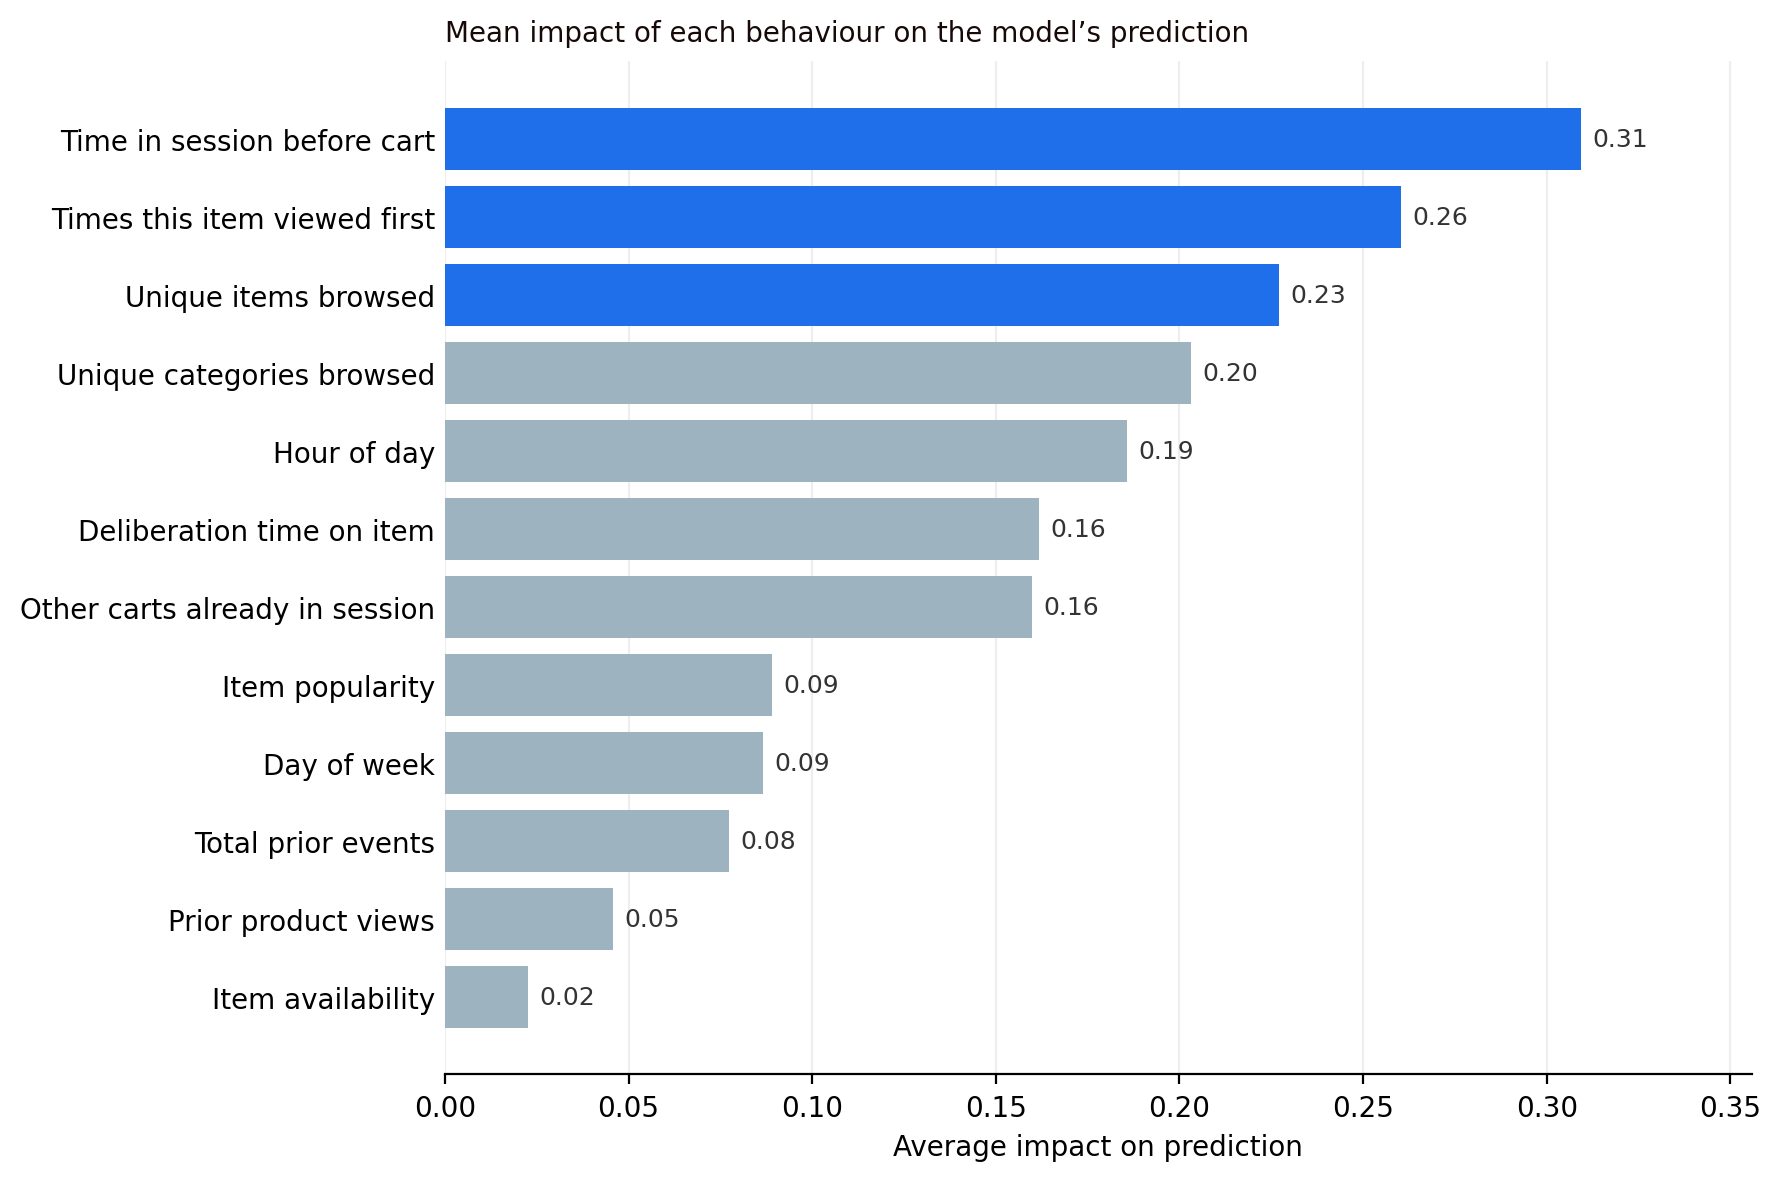

In [22]:
pretty = {
    'mins_into_session':     'Time in session before cart',
    'item_prior_views':      'Times this item viewed first',
    'prior_unique_items':    'Unique items browsed',
    'prior_unique_cats':     'Unique categories browsed',
    'event_hour':            'Hour of day',
    'mins_since_first_view': 'Deliberation time on item',
    'prior_carts':           'Other carts already in session',
    'item_popularity':       'Item popularity',
    'event_dow':             'Day of week',
    'prior_events':          'Total prior events',
    'prior_views':           'Prior product views',
    'available':             'Item availability',
}


imp = (pd.DataFrame({'feature': feature_cols,
                     'value': np.abs(shap_values).mean(axis=0)})
         .sort_values('value', ascending=True)
         .reset_index(drop=True))
imp['label'] = imp['feature'].map(pretty).fillna(imp['feature'])


n = len(imp)
colors = ['#9db4c0'] * n
for i in range(n - 3, n):
    colors[i] = '#1f6feb'

fig, ax = plt.subplots(figsize=(9, 6), dpi=200)
bars = ax.barh(imp['label'], imp['value'], color=colors, edgecolor='none')

for bar, v in zip(bars, imp['value']):
    ax.text(v + imp['value'].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}', va='center', ha='left', fontsize=9, color='#333333')


ax.text(0, 1.02, 'Mean impact of each behaviour on the model\u2019s prediction ',
        transform=ax.transAxes, fontsize=10, color="#0F0000F6")
"#110101"
ax.set_xlabel('Average impact on prediction', fontsize=10)
ax.set_xlim(0, imp['value'].max() * 1.15)
for spine in ('top', 'right', 'left'):
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='x', color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../reports/figures/shap_importance_clean.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

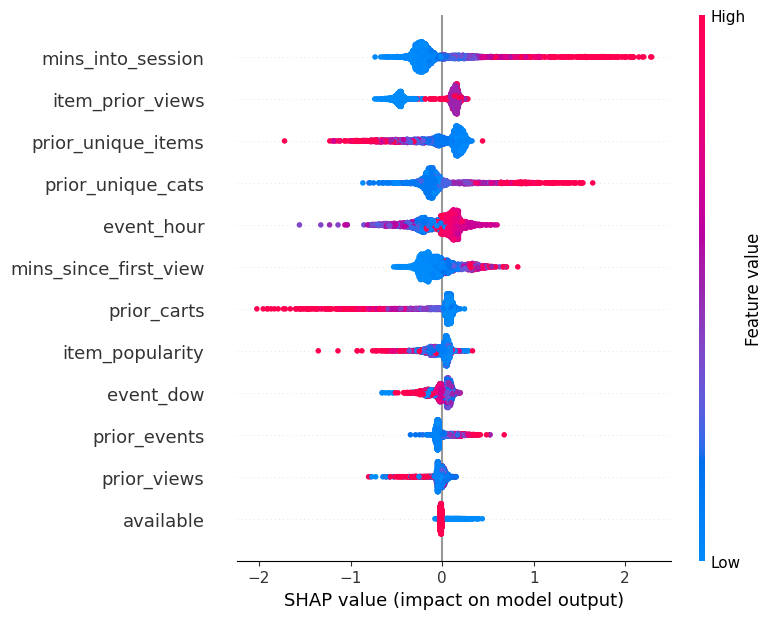

In [15]:
shap.summary_plot(shap_values, X_sample, show=False)   
plt.tight_layout(); plt.show()

In [16]:
joblib.dump(xgb, 'C:/Users/sadeq/Desktop/Python/Retailrocket/models/xgb_abandonment.pkl')
joblib.dump(scaler, 'C:/Users/sadeq/Desktop/Python/Retailrocket/models/scaler.pkl')

['C:/Users/sadeq/Desktop/Python/Retailrocket/models/scaler.pkl']